# Data Roles Salary Revival

Reviving an older levels.fyi salary analysis project, this time focused on **data-analyst-adjacent roles** over time.

**Source.** The original pipeline pulled `levels.fyi/js/salaryData.json` (now 403). We use the Kaggle *Data Science and STEM Salaries* dump (~62K rows, **2017-06 → 2021-08**), via a GitHub mirror.

**Role taxonomy.** levels.fyi only encodes a handful of canonical titles, so the data-analyst family is reconstructed from `(title, tag)`:

| Role              | Mapping rule                                         |
|-------------------|------------------------------------------------------|
| Data Scientist    | `title == "Data Scientist"`                          |
| Business Analyst  | `title == "Business Analyst"` *(closest stand-in for Data Analyst)* |
| Data Engineer     | `title == "Software Engineer"` & `tag in {Data, Analytics}` |
| ML Engineer       | `title == "Software Engineer"` & `tag in {ML / AI, Machine Learning, Data Science}` |

*Caveats.* "Data Analyst" and "Analytics Engineer" aren't first-class titles in this dataset — Business Analyst and Data Engineer are the nearest matches respectively. Per-role outliers below the 5th and above the 95th percentile on total comp are trimmed.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import levels_fyi

sns.set_theme(style='whitegrid', context='notebook')
ROLE_ORDER = ['Business Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer']
ROLE_PALETTE = dict(zip(ROLE_ORDER, sns.color_palette('Set2', n_colors=4)))

df = levels_fyi.build()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['quarter_dt'] = df['timestamp'].dt.to_period('Q').dt.to_timestamp()
print(f'rows: {len(df):,}')
print(f"date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
df['role'].value_counts().reindex(ROLE_ORDER)

rows: 5,422
date range: 2018-06-05 → 2021-08-17


role
Business Analyst     671
Data Scientist      2013
Data Engineer        706
ML Engineer         2032
Name: count, dtype: int64

## 1. Sample size over time

Before reading anything into the trends, look at how many submissions back them up each quarter — the dataset's coverage of data roles grows substantially through 2019-2020.

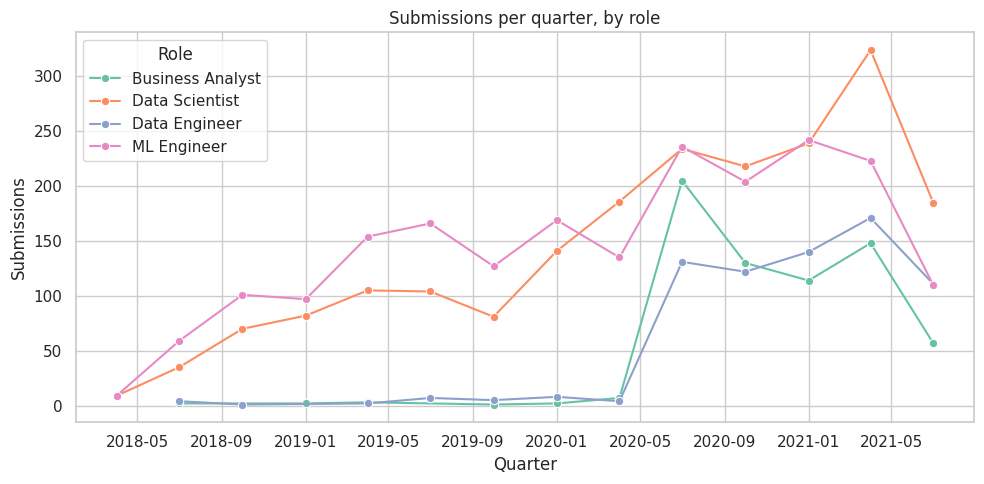

In [2]:
counts = df.groupby(['quarter_dt', 'role']).size().reset_index(name='n')
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(counts, x='quarter_dt', y='n', hue='role', hue_order=ROLE_ORDER,
             palette=ROLE_PALETTE, marker='o', ax=ax)
ax.set_title('Submissions per quarter, by role')
ax.set_xlabel('Quarter')
ax.set_ylabel('Submissions')
ax.legend(title='Role', loc='upper left')
plt.tight_layout()

## 2. Median total comp over time

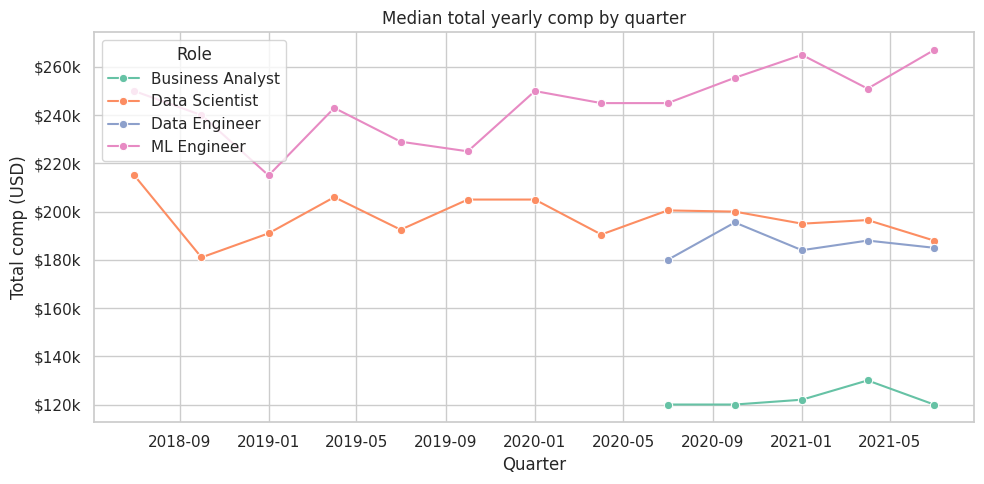

In [3]:
trend = (df.groupby(['quarter_dt', 'role'])['totalyearlycompensation']
           .median().reset_index())
# Suppress quarter/role cells with very few observations so noise doesn't drive the line.
n = df.groupby(['quarter_dt', 'role']).size().reset_index(name='n')
trend = trend.merge(n).query('n >= 10')

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(trend, x='quarter_dt', y='totalyearlycompensation', hue='role',
             hue_order=ROLE_ORDER, palette=ROLE_PALETTE, marker='o', ax=ax)
ax.set_title('Median total yearly comp by quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total comp (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role', loc='upper left')
plt.tight_layout()

## 3. Distribution of total comp by role

/tmp/ipykernel_5753/1203511357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x='role', y='totalyearlycompensation', order=ROLE_ORDER,


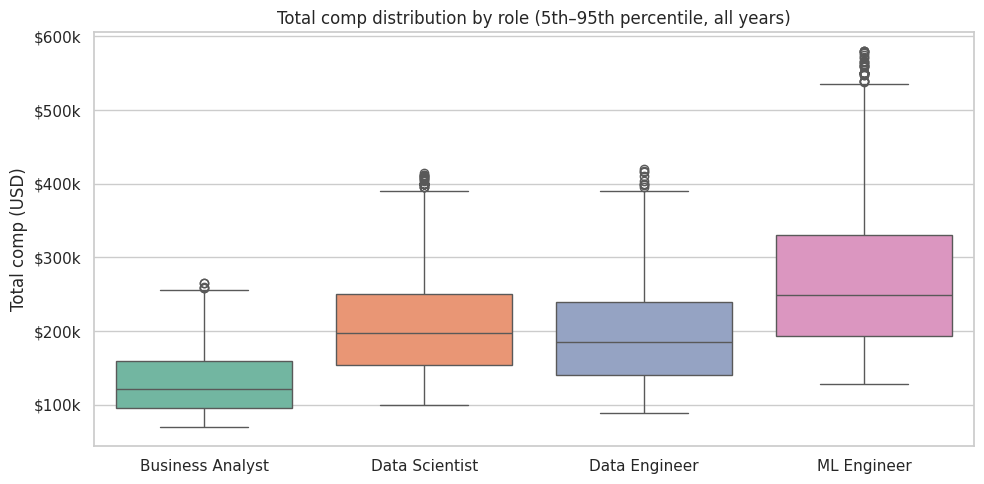

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(df, x='role', y='totalyearlycompensation', order=ROLE_ORDER,
            palette=ROLE_PALETTE, ax=ax)
ax.set_title('Total comp distribution by role (5th–95th percentile, all years)')
ax.set_xlabel('')
ax.set_ylabel('Total comp (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
plt.tight_layout()

## 4. Compensation mix: base vs stock vs bonus

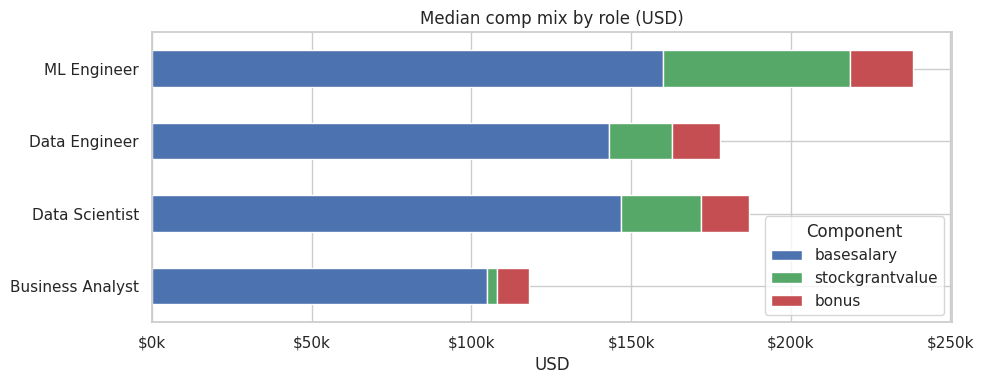

In [5]:
mix = (df.groupby('role')[['basesalary', 'stockgrantvalue', 'bonus']]
          .median().reindex(ROLE_ORDER))
ax = mix.plot(kind='barh', stacked=True, figsize=(10, 4),
              color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Median comp mix by role (USD)')
ax.set_xlabel('USD')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Component', loc='lower right')
plt.tight_layout()

## 5. Experience vs total comp

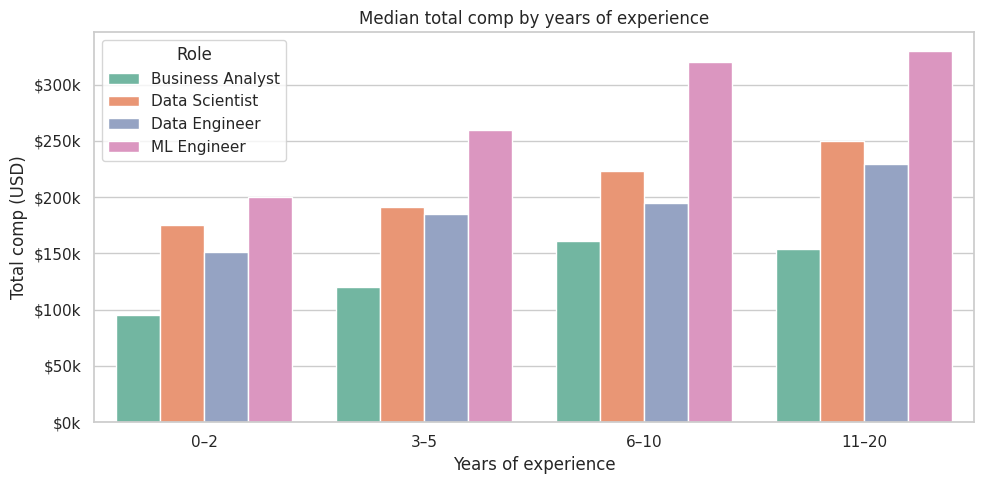

In [6]:
yoe = df[df['yearsofexperience'].between(0, 20)].copy()
yoe['yoe_bucket'] = pd.cut(yoe['yearsofexperience'],
                           bins=[-0.1, 2, 5, 10, 20],
                           labels=['0–2', '3–5', '6–10', '11–20'])
agg = (yoe.groupby(['yoe_bucket', 'role'], observed=True)['totalyearlycompensation']
          .median().reset_index())
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(agg, x='yoe_bucket', y='totalyearlycompensation', hue='role',
            hue_order=ROLE_ORDER, palette=ROLE_PALETTE, ax=ax)
ax.set_title('Median total comp by years of experience')
ax.set_xlabel('Years of experience')
ax.set_ylabel('Total comp (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role')
plt.tight_layout()

## 6. Top-paying companies, by role

Median total comp, restricted to companies with at least 10 submissions for the role.

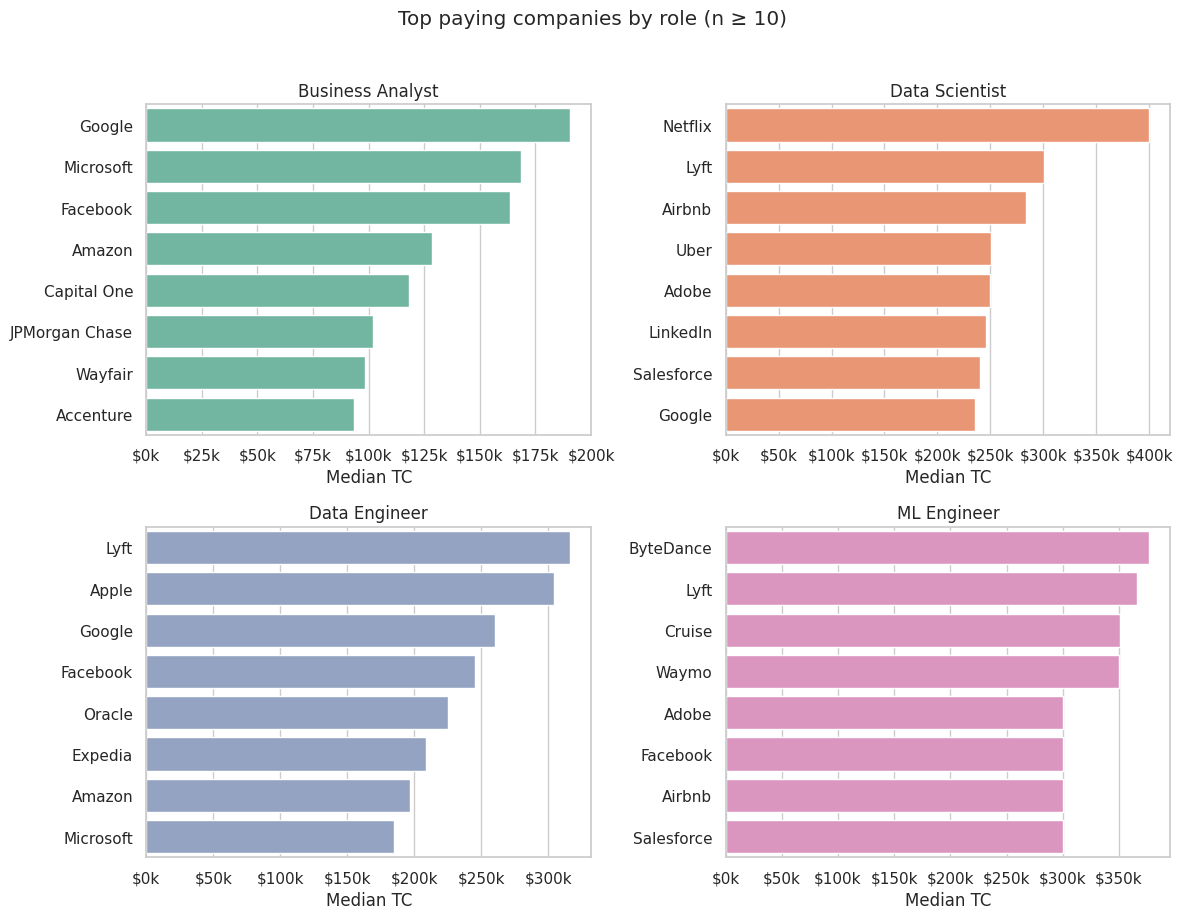

In [7]:
comp_role = df.groupby(['role', 'company']).agg(
    median_tc=('totalyearlycompensation', 'median'),
    n=('totalyearlycompensation', 'size'),
).reset_index().query('n >= 10')

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
for ax, role in zip(axes.flat, ROLE_ORDER):
    top = (comp_role[comp_role['role'] == role]
           .sort_values('median_tc', ascending=False).head(8))
    if top.empty:
        ax.set_visible(False)
        continue
    sns.barplot(top, y='company', x='median_tc',
                color=ROLE_PALETTE[role], ax=ax)
    ax.set_title(f'{role}')
    ax.set_xlabel('Median TC')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
fig.suptitle('Top paying companies by role (n ≥ 10)', y=1.02)
plt.tight_layout()

## 7. Geographic spread — top metros

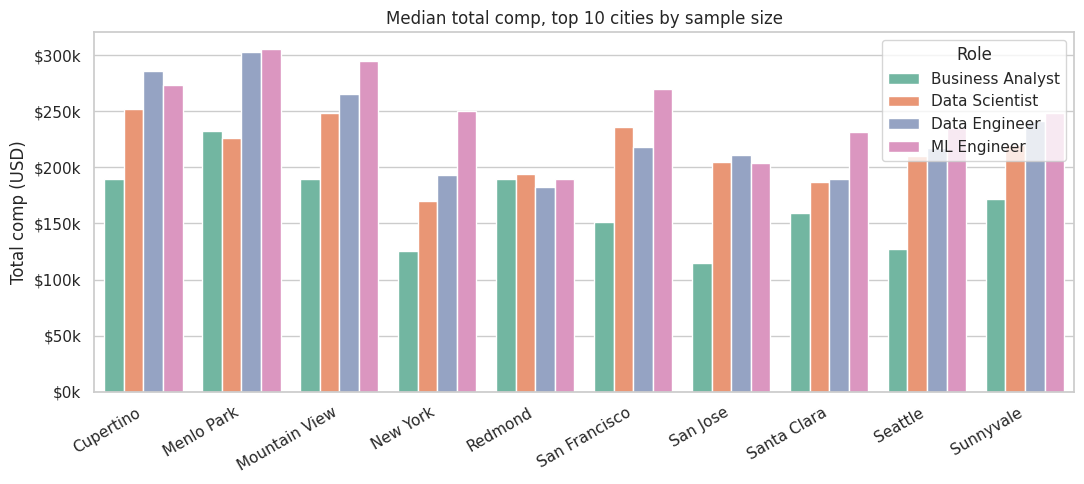

In [8]:
top_cities = (df.groupby('city').size().sort_values(ascending=False).head(10).index)
geo = (df[df['city'].isin(top_cities)]
         .groupby(['city', 'role'])['totalyearlycompensation']
         .median().reset_index())
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(geo, x='city', y='totalyearlycompensation', hue='role',
            hue_order=ROLE_ORDER, palette=ROLE_PALETTE, ax=ax)
ax.set_title('Median total comp, top 10 cities by sample size')
ax.set_xlabel('')
ax.set_ylabel('Total comp (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Role', loc='upper right')
plt.tight_layout()

## Summary table

In [9]:
summary = df.groupby('role').agg(
    n=('totalyearlycompensation', 'size'),
    median_tc=('totalyearlycompensation', 'median'),
    p25_tc=('totalyearlycompensation', lambda s: s.quantile(0.25)),
    p75_tc=('totalyearlycompensation', lambda s: s.quantile(0.75)),
    median_base=('basesalary', 'median'),
    median_stock=('stockgrantvalue', 'median'),
    median_yoe=('yearsofexperience', 'median'),
).reindex(ROLE_ORDER).round(0).astype(int)
summary

,n,median_tc,p25_tc,p75_tc,median_base,median_stock,median_yoe
role,,,,,,,
Business Analyst,671,121000,96000,160000,105000,3000,5
Data Scientist,2013,198000,154000,250000,147000,25000,4
Data Engineer,706,185000,140000,240000,143000,20000,5
ML Engineer,2032,248500,193000,330000,160000,58500,4


## Next steps

- The dataset ends in **Aug 2021** — to extend the timeline through the 2022-2024 hiring slowdown we'd need a fresher source (current candidates: ai-jobs.net's `salaries.csv`, a scrape of levels.fyi's current site, or BLS OEWS for a govt baseline).
- *Analytics Engineer* didn't exist as a distinct title in the levels.fyi taxonomy of this era; consider adding it as a first-class role once we ingest a 2022+ source where it's used.
- The `level` column is messy (company-specific). Normalizing it into a coarse ladder (junior / mid / senior / staff+) would make role-vs-role comparisons cleaner.